/home/jjpark/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-18 15:23:57.887959: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742279037.900534  107378 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742279037.904528  107378 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-18 15:23:57.917880: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations

Using device: cuda


Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  4.85it/s]


Error loading image: [Errno 2] No such file or directory: '/home/jjpark/SKKAI/URP/data/fruit.png'
Using placeholder image from: https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg


100%|██████████| 15/15 [00:03<00:00,  3.80it/s]


Image saved as output.png


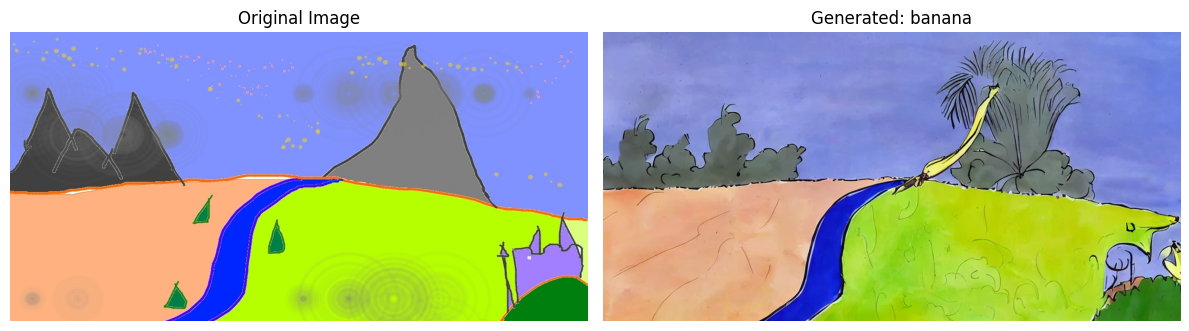

In [1]:
import torch
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Helper function to load image from file or URL
def load_image(image_path_or_url):
    """Load an image from file or URL"""
    if image_path_or_url.startswith(('http://', 'https://')):
        response = requests.get(image_path_or_url)
        image = Image.open(BytesIO(response.content))
    else:
        image = Image.open(image_path_or_url)
    image = image.convert("RGB")
    return image

# Parameters (similar to your original code)
prompt = "banana"  # replace with desired prompt
source_image_path = "data/fruit.png"  # replace with actual path
num_inference_steps = 20
guidance_scale = 10.0
seed = 42

# Set seed for reproducibility
torch.manual_seed(seed)

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load model
model_id = "runwayml/stable-diffusion-v1-5"  # or any other SD model
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id, 
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)
pipe = pipe.to(device)

# Load and prepare the input image
try:
    init_image = load_image(source_image_path)
    width, height = init_image.size
    # Resize to multiple of 8 if needed
    if width % 8 != 0 or height % 8 != 0:
        width = (width // 8) * 8
        height = (height // 8) * 8
        init_image = init_image.resize((width, height))
    
    print(f"Loaded image with dimensions: {width}x{height}")
except Exception as e:
    print(f"Error loading image: {e}")
    # Use a placeholder image URL if local file doesn't exist
    placeholder_url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
    print(f"Using placeholder image from: {placeholder_url}")
    init_image = load_image(placeholder_url)
    width, height = init_image.size

# Generate image
generator = torch.Generator(device).manual_seed(seed)
images = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,  # How much to transform the image (0-1)
    guidance_scale=guidance_scale,
    num_inference_steps=num_inference_steps,
    generator=generator
).images

# Save results
result_image = images[0]
result_image.save("output.png")
print("Image saved as output.png")

# Display images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(init_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_image)
plt.title(f"Generated: {prompt}")
plt.axis("off")

plt.tight_layout()
plt.show()